In [1]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage,SystemMessage

load_dotenv()
llm = ChatOpenAI(
    model="deepseek-v4-flash",
    api_key = os.getenv("DEEPSEEK_API_KEY"),
    #api_key=os.environ["DEEPSEEK_API_KEY"],  # 或者用你已读取出来的 DeepSeek_API_KEY 变量
    base_url="https://api.deepseek.com",
    temperature=0,
    extra_body={
        "thinking": {
            "type": "disabled"
        }
    }
)
response = llm.invoke([
    SystemMessage(content="你是一名认真负责的大模型应用开发就业导师"),
    HumanMessage(content="你是什么模型")
])
print(response)

content='我是DeepSeek最新版模型，由深度求索公司创造。我是一个纯文本AI助手，擅长回答各种问题、提供信息、协助创作和解决问题。\n\n我的特点包括：\n- **免费使用**：无需付费即可享受服务\n- **超长上下文**：支持1M上下文，可以一次性处理大量文本（比如整本书）\n- **文件上传**：支持上传图片、PDF、Word、Excel等文件，并读取其中的文字信息\n- **联网搜索**：支持联网功能（需要手动开启）\n- **多平台支持**：有Web版和App版，App还支持语音输入\n\n如果你对我的具体版本号或技术细节感兴趣，建议查阅DeepSeek官方文档和公告，那里会有更详细的技术说明。\n\n有什么我可以帮你的吗？无论是学习、工作还是生活问题，我都很乐意协助你！😊' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 179, 'prompt_tokens': 17, 'total_tokens': 196, 'completion_tokens_details': None, 'compute_units': None, 'prompt_tokens_details': {'audio_tokens': None, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 17}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'a26a7955944dc5c60445bff77fac9c8e', 'id': 'abb82857-fe4f-4b65-9964-061320311b00', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--01a05ca3-e6cf-76f1-b4ef-

In [2]:
from typing import Literal
from datetime import datetime
from pydantic import BaseModel
from langchain_core.tools import tool

@tool
def write_email(to: str, subject: str, content: str) -> str:
    """Write and send an email."""
    return f"Email sent to {to} with subject '{subject}' and content: {content}"

@tool
def schedule_meeting(
    attendees: list[str], subject: str, duration_minutes: int, preferred_day: datetime, start_time: int
) -> str:
    """Schedule a calendar meeting."""
    # Placeholder response - in real app would check calendar and schedule
    date_str = preferred_day.strftime("%A, %B %d, %Y")
    return f"Meeting '{subject}' scheduled on {date_str} at {start_time} for {duration_minutes} minutes with {len(attendees)} attendees"

@tool
def check_calendar_availability(day: str) -> str:
    """Check calendar availability for a given day."""
    # Placeholder response - in real app would check actual calendar
    return f"Available times on {day}: 9:00 AM, 2:00 PM, 4:00 PM"

@tool
# This is new! 
class Question(BaseModel):
      """Question to ask user."""
      content: str

@tool
class Done(BaseModel):
      """E-mail has been sent."""
      done: bool


tools = [write_email, schedule_meeting, check_calendar_availability, Question, Done]

In [ ]:
from langgraph.graph import MessagesState

# 这里继承了 MessageState 本身就已经定义了message
# messages: list 就这个
# 更新的方式是 首先用result接收/记录 然后update让langgraph自动修改
class State(MessagesState):
    email_input: dict
    classification_decision: Literal["ignore", "respond", "notify"]

In [4]:
from typing import Literal
from pydantic import BaseModel, Field
import json

class RouterSchema(BaseModel):
    """
    这是一个 Schema 哦 规定数据必须变成什么样子

    正常情况下普通llm的输出都是自然语言 没有固定格式
    但是通过RouterSchema LLM必须输出schema定义的固定格式

    这是规定LLM分析结果的schema
    分析未读邮件，并根据内容进行路由。
    这个class 也就是schema 包含reasonging 和 classification 两个字段
    {
        reasoning: "...",
        classification: "ignore" | "respond" | "notify"
    }

    Field是告诉python 这个字段需要额外配置
    例如 min_length=3 就是最短长度 如果<3 失败
    description 只是添加说明
    """

    reasoning: str = Field(
        description="Step-by-step reasoning behind the classification."
    )
    """ 
    from typing import Literal 表示这个变量只能取指定值
    """
    classification: Literal["ignore", "respond", "notify"] = Field(
        description="The classification of an email: 'ignore' for irrelevant emails, "
        "'notify' for important information that doesn't need a response, "  # 重要但是不需要回复
        "'respond' for emails that need a reply",
    )

# 这里ds不支持 response_format 类型
# llm_router = llm.with_structured_output(RouterSchema) 
# response = llm_router.invoke([
#     SystemMessage(content="你负责分析邮件并分类"),
#     HumanMessage(content="邮件:老板邀请我参加明天上午10点的项目会议。")
# ])
# print(response)

""" 
llm.bind 的意思是给当前llm永久绑定一些调用参数 比如temperature = 0 
response_format 就是额外告诉模型 返回json 也可以在invoke中绑定
"""
llm_json = llm.bind(
    response_format={"type": "json_object"}
)
""" 
这里可以看出 llm是无状态的
上一个cell传入的systemmessage  这里不会记录
"""
raw_result = llm_json.invoke([
    SystemMessage(content="""
        你负责分析邮件并分类。你必须只返回 JSON。

        格式：
        {
        "reasoning": "分类理由",
        "classification": "ignore | respond | notify"
        }

        classification 只能是 ignore、respond、notify。
    """),
])
print(type(raw_result))
print(raw_result) # AImessage

data = json.loads(raw_result.content)
print(type(data))
print(data)

# 按照RouterSchema的规则再检查一遍
response = RouterSchema.model_validate(data)

print(type(response))
print(response)
print(response.reasoning)
print(response.classification)

<class 'langchain_core.messages.ai.AIMessage'>
content='{\n  "reasoning": "邮件内容为空白，没有提供任何信息，无法判断是否需要回复或通知，因此归类为忽略。",\n  "classification": "ignore"\n}' additional_kwargs={'parsed': None, 'refusal': None} response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 76, 'total_tokens': 114, 'completion_tokens_details': None, 'compute_units': None, 'prompt_tokens_details': {'audio_tokens': None, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 76}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'a26a7955944dc5c60445bff77fac9c8e', 'id': '9be88e6c-18a7-4707-99de-9a1c9a07373b', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--01a05ca4-87ad-7b70-bb2c-dd50d9fdab5b-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 76, 'output_tokens': 38, 'total_tokens': 114, 'input_token_details': {'cache_read': 0}, 'output_token_de

In [39]:
test_email = """
From: Alice Smith <alice@company.com>
To: Lance Martin <lance@company.com>
Subject: Quick question about API docs

Hi Lance,

I was reviewing the API documentation for the new authentication service and noticed
that the /auth/refresh endpoint seems to be missing. Could you help clarify whether
this was intentional or whether we should update the docs?

Thanks,
Alice
"""

result = llm_json.invoke([
    SystemMessage(content="""
        你负责分析邮件并分类。你必须只返回 JSON。

        格式：
        {
          "reasoning": "分类理由",
          "classification": "ignore | respond | notify"
        }

        classification 只能是 ignore、respond、notify。
        """),
    HumanMessage(content=f"请分析下面这封邮件,返回json：\n\n{test_email}")])
print(type(result))
print(result) 

data = json.loads(result.content)
print(type(data))
print(data)

# 按照RouterSchema的规则再检查一遍
response = RouterSchema.model_validate(data)

print(type(response))
print(response)
print(response.reasoning)
print(response.classification)

<class 'langchain_core.messages.ai.AIMessage'>
content='{\n  "reasoning": "邮件来自同事，询问关于API文档的具体问题，需要回复以澄清或提供信息。",\n  "classification": "respond"\n}' additional_kwargs={'parsed': None, 'refusal': None} response_metadata={'token_usage': {'completion_tokens': 35, 'prompt_tokens': 167, 'total_tokens': 202, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 167}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'a26a7955944dc5c60445bff77fac9c8e', 'id': 'a1ff91c8-e3c1-405a-ac01-5c08586ec88b', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--01a05c0d-3443-7602-a525-51f6188b6148-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 167, 'output_tokens': 35, 'total_tokens': 202, 'input_token_details': {'cache_read': 0}, 'output_token_details': {}}
<class 'dict'>
{'reasoning': '邮件来自同事，询问关于API文档的具体问题，需要回复以澄清或提供信息。', 'classificatio

In [ ]:
def parse_email(email_input: dict):
    """
    从  邮件dict中 吧重要的信息拆出来

    Args:
        email_input (dict): Dictionary containing email fields:
            - author: Sender's name and email
            - to: Recipient's name and email
            - subject: Email subject line
            - email_thread: Full email content

    Returns:
        tuple[str, str, str, str]: Tuple containing:
            - author: Sender's name and email
            - to: Recipient's name and email
            - subject: Email subject line
            - email_thread: Full email content
    """
    return (
        email_input["author"],
        email_input["to"],
        email_input["subject"],
        email_input["email_thread"],
    )


def format_email_markdown(subject, author, to, email_thread, email_id=None):
    """
    把邮件内容变成 Md 格式
    
    Args:
        subject: Email subject
        author: Email sender
        to: Email recipient
        email_thread: Email content
        email_id: Optional email ID (for Gmail API)
    """
    id_section = f"\n**ID**: {email_id}" if email_id else ""
    
    return f"""

    **Subject**: {subject}
    **From**: {author}
    **To**: {to}{id_section}

    {email_thread}

    ---
    """

In [44]:
test_email = {
    "author": "Alice Smith <alice@company.com>",
    "to": "Lance Martin <lance@company.com>",
    "subject": "Quick question about API docs",
    "email_thread": """Hi Lance,

I was reviewing the API documentation for the new authentication service and noticed
that the /auth/refresh endpoint seems to be missing. Could you help clarify whether
this was intentional or whether we should update the docs?

Thanks,
Alice"""
}
author, to, subject, email_thread = parse_email(test_email)
email_md = format_email_markdown(
    subject=subject,
    author=author,
    to=to,
    email_thread=email_thread
)

print(type(email_md))
print(email_md)

<class 'str'>


**Subject**: Quick question about API docs
**From**: Alice Smith <alice@company.com>
**To**: Lance Martin <lance@company.com>

Hi Lance,

I was reviewing the API documentation for the new authentication service and noticed
that the /auth/refresh endpoint seems to be missing. Could you help clarify whether
this was intentional or whether we should update the docs?

Thanks,
Alice

---



In [45]:
from langgraph.graph import END
from langgraph.types import Command
from prompts import triage_system_prompt, triage_user_prompt, default_background, default_triage_instructions
""" 
Command 状态怎么修改 + 下一步去哪
goto 就是下一步去哪
update 就是修改哪些信息
"""
def triage_router(state: State) -> Command[Literal["response_agent", "__end__"]]:
    """ 
    分析邮件 决定是respond / notify / ignore
    """
    author, to, subject, email_thread = parse_email(state["email_input"])
    system_prompt = triage_system_prompt.format(
        background=default_background,
        triage_instructions=default_triage_instructions
    )
    user_prompt = triage_user_prompt.format(
        author=author, to=to, subject=subject, email_thread=email_thread
    )

    # raw_result = llm_json.invoke(
    #     [
    #         {"role": "system", "content": system_prompt},
    #         {"role": "user", "content": user_prompt},
    #     ]
    # )
    result = llm_json.invoke([
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_prompt),
    ])
    
    data = json.loads(raw_result.content)
    result = RouterSchema.model_validate(data)

    if result.classification == "respond":
        print("📧 Classification: RESPOND - This email requires a response")
        goto = "response_agent"
        update = {
            "messages": [
                {
                    "role": "user",
                    "content": f"Respond to the email: \n\n{format_email_markdown(subject, author, to, email_thread)}",
                }
            ],
            "classification_decision": result.classification,
        }
        
    elif result.classification == "ignore":
        print("🚫 Classification: IGNORE - This email can be safely ignored")
        goto = END
        update =  {
            "classification_decision": result.classification,
        }
        
    elif result.classification == "notify":
        print("🔔 Classification: NOTIFY - This email contains important information")
        # For now, we go to END. But we will add to this later!
        goto = END
        update = {
            "classification_decision": result.classification,
        }
        
    else:
        raise ValueError(f"Invalid classification: {result.classification}")
    return Command(goto=goto, update=update)

In [2]:
from prompts import triage_system_prompt
print (triage_system_prompt)



< Role >
Your role is to triage incoming emails based upon instructs and background information below.
</ Role >

< Background >
{background}. 
</ Background >

< Instructions >
Categorize each email into one of three categories:
1. IGNORE - Emails that are not worth responding to or tracking
2. NOTIFY - Important information that worth notification but doesn't require a response
3. RESPOND - Emails that need a direct response
Classify the below email into one of these categories.
</ Instructions >

< Rules >
{triage_instructions}
</ Rules >



In [46]:
from prompts import agent_system_prompt, default_response_preferences, default_cal_preferences
from prompt_templates import AGENT_TOOLS_PROMPT
load_dotenv()
llm = ChatOpenAI(
    model="deepseek-v4-flash",
    api_key = os.getenv("DEEPSEEK_API_KEY"),
    #api_key=os.environ["DEEPSEEK_API_KEY"],  # 或者用你已读取出来的 DeepSeek_API_KEY 变量
    base_url="https://api.deepseek.com",
    temperature=0,
    extra_body={
        "thinking": {
            "type": "disabled"
        }
    }
)
llm_with_tools = llm.bind_tools(tools, tool_choice="any")
def llm_call(state:State):
    """
    决定是否使用工具 
    """
    return {
        "messages": [
            # Invoke the LLM
            llm_with_tools.invoke(
                # Add the system prompt
                [   
                    {"role": "system", "content": agent_system_prompt.format(
                        tools_prompt=AGENT_TOOLS_PROMPT,
                        background=default_background,
                        response_preferences=default_response_preferences,
                        cal_preferences=default_cal_preferences, 
                    )}
                ]
                # Add the current messages to the prompt
                + state["messages"]
            )
        ]
    }

In [8]:
tools_by_name = {tool.name: tool for tool in tools}
print(tools_by_name)

{'write_email': StructuredTool(name='write_email', description='Write and send an email.', args_schema=<class 'langchain_core.utils.pydantic.write_email'>, func=<function write_email at 0x00000284D44BBF40>), 'schedule_meeting': StructuredTool(name='schedule_meeting', description='Schedule a calendar meeting.', args_schema=<class 'langchain_core.utils.pydantic.schedule_meeting'>, func=<function schedule_meeting at 0x00000284D567A290>), 'check_calendar_availability': StructuredTool(name='check_calendar_availability', description='Check calendar availability for a given day.', args_schema=<class 'langchain_core.utils.pydantic.check_calendar_availability'>, func=<function check_calendar_availability at 0x00000284D567A320>), 'Done': StructuredTool(name='Done', description='E-mail has been sent.', args_schema=<class 'langchain_core.utils.pydantic.Done'>, func=<class '__main__.Done'>)}


In [17]:
def tool_handler(state:State):
    """
    执行工具
    """
    result = []
    # Iterate through tool calls
    for tool_call in state["messages"][-1].tool_calls:
        # Get the tool
        tool = tools_by_name[tool_call["name"]]
        # Run it
        observation = tool.invoke(tool_call["args"])
        # Create a tool message
        result.append({"role": "tool", "content" : observation, "tool_call_id": tool_call["id"]})
    
    # Add it to our messages
    return {"messages": result}

In [18]:
def should_continue(state: State) -> Literal["tool_handler", "__end__"]:
    """
    决定路由到哪里
    是调用工具还是结束
    """
    
    # Get the last message
    messages = state["messages"]
    last_message = messages[-1]
    
    # Check if it's a Done tool call
    if last_message.tool_calls:
        for tool_call in last_message.tool_calls: 
            if tool_call["name"] == "Done":
                return END
            else:
                return "tool_handler"

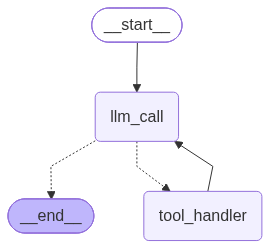

In [20]:
from langgraph.graph import StateGraph, START, END
workflow = StateGraph(State)
workflow.add_node("llm_call", llm_call)
workflow.add_node("tool_handler", tool_handler)

workflow.add_edge(START, "llm_call")
workflow.add_conditional_edges("llm_call",
    should_continue,
    {
        "tool_handler": "tool_handler",
        END: END,
    },
)
workflow.add_edge("tool_handler", "llm_call")
agent = workflow.compile()
agent

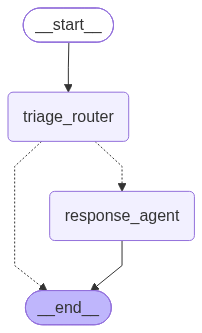

In [24]:
overall_workflow = (
    StateGraph(State)
    .add_node(triage_router)
    .add_node("response_agent", agent)
    .add_edge(START, "triage_router")
).compile()
overall_workflow

In [47]:
from email_dataset import email_inputs, expected_tool_calls, triage_outputs_list, response_criteria_list

test_case_ix = 0

print("Email Input:", email_inputs[test_case_ix])
print("Expected Triage Output:", triage_outputs_list[test_case_ix])
print("Expected Tool Calls:", expected_tool_calls[test_case_ix])
print("Response Criteria:", response_criteria_list[test_case_ix])

Email Input: {'author': 'Alice Smith <alice.smith@company.com>', 'to': 'Lance Martin <lance@company.com>', 'subject': 'Quick question about API documentation', 'email_thread': "Hi Lance,\n\nI was reviewing the API documentation for the new authentication service and noticed a few endpoints seem to be missing from the specs. Could you help clarify if this was intentional or if we should update the docs?\n\nSpecifically, I'm looking at:\n- /auth/refresh\n- /auth/validate\n\nThanks!\nAlice"}
Expected Triage Output: respond
Expected Tool Calls: ['write_email', 'done']
Response Criteria: 
• Send email with write_email tool call to acknowledge the question and confirm it will be investigated  



In [ ]:
import pytest

: 

In [6]:
from langgraph.types import interrupt, Command

def triage_interrupt_handler(state: State) -> Command[Literal["response_agent", "__end__"]]:
    author, to, subject, email_thread = parse_email(state["email_input"])
 
    email_markdown = format_email_markdown(subject, author, to, email_thread)

    messages = [{"role": "user",
                "content": f"Email to notify user about: {email_markdown}"
                }]

    request = {
        "action_request": {
            "action": f"Email Assistant: {state['classification_decision']}",
            "args": {}
        },
        "config": {
            "allow_ignore": True,  
            "allow_respond": True, 
            "allow_edit": False, 
            "allow_accept": False,  
        },
        # Email to show in Agent Inbox
        "description": email_markdown,
    }


    # 这里的意思是
    # interrupt 告诉langgraph 这里需要暂停等待用户输入 ([request]) 就是说期望得到request类型的内容
    # 然后等待用户的输入 输入的结果会被存储为 response
    response = interrupt([request])[0]

    # If user provides feedback, go to response agent and use feedback to respond to email   
    if response["type"] == "response":
        # Add feedback to messages 
        user_input = response["args"]
        # Used by the response agent
        messages.append({"role": "user",
                        "content": f"User wants to reply to the email. Use this feedback to respond: {user_input}"
                        })
        # Go to response agent
        goto = "response_agent"

    elif response["type"] == "ignore":
        goto = END

    else:
        raise ValueError(f"Invalid response: {response}")

    update = {
        "messages": messages,
    }

    return Command(goto=goto, update=update)

In [8]:
def format_for_display(tool_call):
    """Format content for display in Agent Inbox
    
    Args:
        tool_call: The tool call to format
    """
    # Initialize empty display
    display = ""
    
    # Add tool call information
    if tool_call["name"] == "write_email":
        display += f"""# Email Draft

**To**: {tool_call["args"].get("to")}
**Subject**: {tool_call["args"].get("subject")}

{tool_call["args"].get("content")}
"""
    elif tool_call["name"] == "schedule_meeting":
        display += f"""# Calendar Invite

**Meeting**: {tool_call["args"].get("subject")}
**Attendees**: {', '.join(tool_call["args"].get("attendees"))}
**Duration**: {tool_call["args"].get("duration_minutes")} minutes
**Day**: {tool_call["args"].get("preferred_day")}
"""
    elif tool_call["name"] == "Question":
        # Special formatting for questions to make them clear
        display += f"""# Question for User

{tool_call["args"].get("content")}
"""
    else:
        # Generic format for other tools
        display += f"""# Tool Call: {tool_call["name"]}

Arguments:"""
        
        # Check if args is a dictionary or string
        if isinstance(tool_call["args"], dict):
            display += f"\n{json.dumps(tool_call['args'], indent=2)}\n"
        else:
            display += f"\n{tool_call['args']}\n"
    return display


![overview-img](HITL_flow.png)

In [ ]:
def interrupt_handler(state: State) -> Command[Literal["llm_call", "__end__"]]:
    """ 
    在确定要调用工具之后 如果是不敏感工具 直接执行 但是真正执行敏感工具之前 先把工具调用交给人类审核
    """
    result = []
    goto = "llm_call"
    for tool_call in state["messages"][-1].tool_calls:
        # 这些事需要人工审核的tool
        hitl_tools = ["write_email", "schedule_meeting", "Question"]
        if tool_call["name"] not in hitl_tools:
            tool = tools_by_name[tool_call["name"]]
            observation = tool.invoke(tool_call["args"])
            # 告诉llm 刚才的那个tool已经执行完成了 这是结果
            result.append({"role": "tool", "content": observation, "tool_call_id": tool_call["id"]})
            continue

        # 接下来就是需要人工审核的情况
        email_input= state["email_input"]
        author, to, subject, email_thread = parse_email(email_input)
        original_email_markdown = format_email_markdown(subject, author, to, email_thread)

        # 把原邮件、工具调用格式化为用户容易看懂的内容
        tool_display = format_for_display(tool_call)
        description = original_email_markdown + tool_display

        if tool_call["name"] == "write_email":
            config = {
                "allow_ignore": True,
                "allow_respond": True,
                "allow_edit": True,
                "allow_accept": True,
            }
        elif tool_call["name"] == "schedule_meeting":
            config = {
                "allow_ignore": True,
                "allow_respond": True,
                "allow_edit": True,
                "allow_accept": True,
            }
        elif tool_call["name"] == "Question":
            config = {
                "allow_ignore": True,
                "allow_respond": True,
                "allow_edit": False,
                "allow_accept": False,
            }
        else:
            raise ValueError(f"Invalid tool call: {tool_call['name']}")

        request = {
            "action_request":{
                "action": tool_call["name"],
                "args": tool_call["args"]
            },
            "config": config,
            "description": description,
        }
        # 用户输入的一般都是自然语言 但是这里期待的是某个格式化的内容
        # 这也就意味着 自然语言输入 和 response这个结构化对象之间 存在一个转换层
        # 不一定是LLM 可能是前端UI直接生成 或者出现表单让用户填写
        # 所以这个格式 是双方事先约定好的格式 这里应该是有前端 所以会这样乱 
        response = interrupt([request])[0] 


        # 开始处理 4种情况

        if response["type"] == "accept":
            tool = tools_by_name[tool_call["name"]]
            observation = tool.invoke(tool_call["args"])
            # 把tool的执行结果包装成 ToolMessage
            result.append({"role": "tool", "content": observation, "tool_call_id": tool_call["id"]})

        elif response["type"] == "edit":
            tool = tools_by_name[tool_call["name"]]
            edited_args = response["args"]["args"]

            ai_message = state["messages"][-1]
            current_id = tool_call["id"] 
            # 创建新的 tool call列表
            updated_tool_calls = [tc for tc in ai_message.tool_calls if tc["id"] != current_id] + [
                {"type": "tool_call", "name": tool_call["name"], "args": edited_args, "id": current_id}
            ]
            # 新的toolcall 和 旧toolcall消息 id相同 那么会自动用新消息覆盖旧消息
            result.append(ai_message.model_copy(update={"tool_calls": updated_tool_calls}))

            if tool_call["name"] == "write_email":
                observation = tool.invoke(edited_args)
                result.append({"role": "tool", "content": observation, "tool_call_id": current_id})

            elif tool_call["name"] == "schedule_meeting":
                observation = tool.invoke(edited_args)
                result.append({"role": "tool", "content": observation, "tool_call_id": current_id})
            
            else:
                raise ValueError(f"Invalid tool call: {tool_call['name']}")

        elif response["type"] == "ignore":
            if tool_call["name"] == "write_email":
                result.append({"role": "tool", "content": "User ignored this email draft. Ignore this email and end the workflow.", "tool_call_id": tool_call["id"]})
                goto = END
            elif tool_call["name"] == "schedule_meeting":
                result.append({"role": "tool", "content": "User ignored this calendar meeting draft. Ignore this email and end the workflow.", "tool_call_id": tool_call["id"]})
                goto = END
            elif tool_call["name"] == "Question":
                result.append({"role": "tool", "content": "User ignored this question. Ignore this email and end the workflow.", "tool_call_id": tool_call["id"]})
                goto = END
            else:
                raise ValueError(f"Invalid tool call: {tool_call['name']}")

        elif response["type"] == "response":
            user_feedback = response["args"]
            if tool_call["name"] == "write_email":
                result.append({"role": "tool", "content": f"User gave feedback, which can we incorporate into the email. Feedback: {user_feedback}", "tool_call_id": tool_call["id"]})
            elif tool_call["name"] == "schedule_meeting":
                result.append({"role": "tool", "content": f"User gave feedback, which can we incorporate into the meeting request. Feedback: {user_feedback}", "tool_call_id": tool_call["id"]})
            elif tool_call["name"] == "Question": 
                result.append({"role": "tool", "content": f"User answered the question, which can we can use for any follow up actions. Feedback: {user_feedback}", "tool_call_id": tool_call["id"]})
            else:
                raise ValueError(f"Invalid tool call: {tool_call['name']}")

        # Catch all other responses
        else:
            raise ValueError(f"Invalid response: {response}")
    # update 是langgraph在更新 state
    update = {
        "messages": result,
    }

    return Command(goto=goto, update=update)

NameError: name 'State' is not defined

In [ ]:
def should_continue(state: State) -> Literal["interrupt_handler", "__end__"]:
    """ 
    route 到 处理工具函数 或者 end
    """
    message = state["messages"]
    last_message = message[-1]
    for tool_call in last_message.tool_calls:
        if tool_call["name"] == "Done":
            return END
        else: 
            return "interrupt_handler"

agent_builder = StateGraph(state)
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("interrupt_handler", interrupt_handler)

agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_Call",
    should_continue,
    {
        "interrupt_handler": "interrupt_handler",
        END: END,
    },
)

response_agent = agent_builder.compile()